# K-Nearest Neighbors Masterclass
Executed end-to-end with the Iris dataset and fixed random seed 42. The notebook covers data inspection, leakage-safe preprocessing, a NumPy implementation, scikit-learn validation, cross-validation, tuning, final evaluation, and neighbor-distance diagnostics.

In [1]:
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
SEED = 42
np.random.seed(SEED)
data = load_iris(as_frame=True)
X, y = data.data, data.target
print('Python', sys.version.split()[0])
print('NumPy', np.__version__)
print('Dataset shape:', X.shape)
print('Class counts:', np.bincount(y))

Python 3.13.5
NumPy 2.3.5
Dataset shape: (150, 4)
Class counts: [50 50 50]


## From-scratch classifier
The implementation computes Minkowski distances, selects the nearest rows with `argpartition`, supports uniform or distance voting, and returns normalized class scores.

In [2]:
class KNNClassifierScratch:
    def __init__(self, n_neighbors=5, p=2.0, weights='uniform', epsilon=1e-12):
        self.n_neighbors, self.p, self.weights, self.epsilon = n_neighbors, p, weights, epsilon
    def fit(self, X, y):
        self.X_ = np.asarray(X, float); self.y_ = np.asarray(y); self.classes_ = np.unique(self.y_); return self
    def predict_proba(self, X):
        X = np.asarray(X, float)
        d = np.sum(np.abs(X[:,None,:]-self.X_[None,:,:])**self.p, axis=2)**(1/self.p)
        idx = np.argpartition(d, self.n_neighbors-1, axis=1)[:,:self.n_neighbors]
        nd = np.take_along_axis(d, idx, axis=1); ny = self.y_[idx]
        w = np.ones_like(nd) if self.weights == 'uniform' else 1/np.maximum(nd, self.epsilon)
        scores = np.column_stack([np.sum(w*(ny==c), axis=1) for c in self.classes_])
        return scores/scores.sum(axis=1, keepdims=True)
    def predict(self, X): return self.classes_[np.argmax(self.predict_proba(X), axis=1)]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.25,stratify=y,random_state=SEED)
scaler=StandardScaler(); Xtr=scaler.fit_transform(X_train); Xte=scaler.transform(X_test)
scratch=KNNClassifierScratch(5,weights='distance').fit(Xtr,y_train)
pred=scratch.predict(Xte)
print(f'Train shape: {X_train.shape}; test shape: {X_test.shape}')
print('Scratch accuracy:', round(accuracy_score(y_test,pred),4))
print('Scratch balanced accuracy:', round(balanced_accuracy_score(y_test,pred),4))
print('Scratch macro F1:', round(f1_score(y_test,pred,average='macro'),4))

Train shape: (112, 4); test shape: (38, 4)
Scratch accuracy: 0.9474
Scratch balanced accuracy: 0.9487
Scratch macro F1: 0.9484


In [3]:
library_model=KNeighborsClassifier(n_neighbors=5,weights='distance').fit(Xtr,y_train)
print('Prediction agreement:', np.mean(pred==library_model.predict(Xte)))
print('Maximum probability difference:', np.max(np.abs(scratch.predict_proba(Xte)-library_model.predict_proba(Xte))))

Prediction agreement: 1.0
Maximum probability difference: 0.0


## Cross-validation and hyperparameter tuning
All preprocessing is inside the pipeline so each fold learns scaling only from its training partition.

Best parameters: {'knn__n_neighbors': 3, 'knn__p': 2, 'knn__weights': 'uniform'}
Best CV balanced accuracy: 0.9726


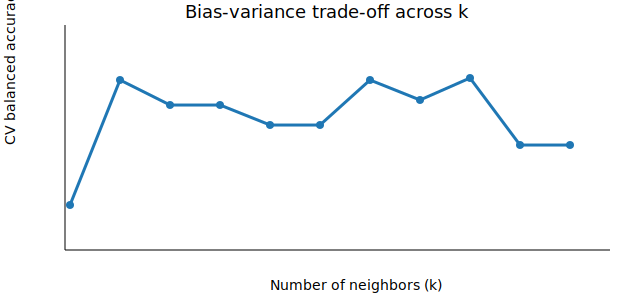

In [4]:
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=SEED)
pipeline=Pipeline([('scale',StandardScaler()),('knn',KNeighborsClassifier())])
grid={'knn__n_neighbors':[3,5,7,9],'knn__weights':['uniform','distance'],'knn__p':[1,2]}
search=GridSearchCV(pipeline,grid,scoring='balanced_accuracy',cv=cv,n_jobs=1).fit(X_train,y_train)
print('Best parameters:', search.best_params_)
print('Best CV balanced accuracy:', round(search.best_score_,4))
ks=list(range(1,22,2)); scores=[]
for k in ks:
    model=Pipeline([('scale',StandardScaler()),('knn',KNeighborsClassifier(n_neighbors=k))])
    scores.append(cross_val_score(model,X_train,y_train,cv=cv,scoring='balanced_accuracy').mean())
plt.plot(ks,scores,marker='o'); plt.xlabel('k'); plt.ylabel('CV balanced accuracy'); plt.title('Bias-variance trade-off'); plt.show()

In [5]:
best=search.best_estimator_; final_pred=best.predict(X_test)
print('Final accuracy:', round(accuracy_score(y_test,final_pred),4))
print('Final balanced accuracy:', round(balanced_accuracy_score(y_test,final_pred),4))
print('Final macro F1:', round(f1_score(y_test,final_pred,average='macro'),4))
print(classification_report(y_test,final_pred,target_names=data.target_names))

Final accuracy: 0.9211
Final balanced accuracy: 0.9231
Final macro F1: 0.9220

              precision    recall  f1-score   support
      setosa       1.00      1.00      1.00        12
  versicolor       0.81      1.00      0.90        13
   virginica       1.00      0.77      0.87        13
    accuracy                           0.92        38


In [6]:
scaled_test=best.named_steps['scale'].transform(X_test)
dist,_=best.named_steps['knn'].kneighbors(scaled_test)
correct=final_pred==y_test.to_numpy(); confidence=best.predict_proba(X_test).max(axis=1)
print('Incorrect predictions mean neighbor distance:', round(dist.mean(axis=1)[~correct].mean(),4))
print('Correct predictions mean neighbor distance:', round(dist.mean(axis=1)[correct].mean(),4))
print('Incorrect predictions mean confidence:', round(confidence[~correct].mean(),4))
print('Correct predictions mean confidence:', round(confidence[correct].mean(),4))

Incorrect predictions mean neighbor distance: 0.6030
Correct predictions mean neighbor distance: 0.4514
Incorrect predictions mean confidence: 0.7778
Correct predictions mean confidence: 0.9714


## Conclusions
KNN depends on representation, distance, and neighborhood size. Scaling must remain inside validation. Cross-validation selects hyperparameters; the untouched test set estimates generalization. Large neighbor distances indicate weak local support and should be monitored in production.